## Example of SDE-matching using a Gaussian Process as marginal distribution

We define a data generating process by the following SDE:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = \begin{bmatrix}
0 & 2 \\
-2 & 0
\end{bmatrix} z_t d_t + 0.6 \cdot dWt
$$

with emission distribution $y_t \sim \mathcal N(y_t\vert z_t, 0.3^2)$ and initial conditions: $z_0 \sim \mathcal N(0, I_2)$

In [1]:

import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import matplotlib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from SDEmatching.distributions.Emission import GaussianEmission
from SDEmatching.distributions.Prior import GaussianPrior
from SDEmatching.core.Diffusions import ScalarDiffusion, SimpleDiffusion
from models import FunctionApproximatorModel, FunctionApproximatorModel_drift
from SDEmatching.core.Marginal import Marginal
from SDEmatching.models.Flows import DDPMflow, NormalFlow, AffineFlow
from SDEmatching.core.SDE import SimpleSDE, SDE, manual_euler_sample
from SDEmatching.utils.utils import torch_seed, to_tensor
import seaborn as sns
from SDEmatching.utils.datageneration import SDEdatagenerator
from SDEmatching.core.SDEproblem import SDEproblem
from plot_functions import plot_parameter_history, plot_marginal
from SDEmatching.models.ConditionMappers import TransformerLatentModel

import numpy as np
import normflows as nf
from torch.utils.data import DataLoader, TensorDataset
import copy
import pandas as pd
#torch.autograd.set_detect_anomaly(True)

In [2]:
# set constants
num_timesteps = 30
num_ts_samples = 30
num_series = 20
#num_samples = 10000
state_dim = 2
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
#device="cpu"

state_dim = 2
t_start = -1
t_end = 1
time_dist = torch.distributions.Uniform(t_start, t_end)

true_diffusion_log_std = torch.tensor(.3).log()
true_prior_log_std = (torch.ones(state_dim, device=device)).log()
true_emission_log_std = torch.tensor(.3).log()

In [3]:
"""
Generating data
"""

# diffusion function  
generator_diffusion = SimpleDiffusion(brownian_dim=2, state_dim=state_dim, log_std=true_diffusion_log_std, device=device, trainable=True)

# drift function
#generator_drift = SimpleDrift(dim=state_dim, device=device)
generator_drift = FunctionApproximatorModel_drift(num_features=state_dim, hidden_layers=[], 
                                                  num_outputs=state_dim, nonlin=torch.nn.ReLU(), seed=2, 
                                                  initial_zero=False, device=device, time_independent=True, bias=False)
generator_drift.hidden_layers[0].weight.data = torch.tensor([[0., 2.], [-2., 0.]], device=device)

# prior
generator_prior = GaussianPrior(mean=torch.ones(state_dim, device=device) * 0., log_std=true_prior_log_std, device=device, trainable=True)

# emission distribution:
generator_emission = GaussianEmission(dim=state_dim, log_std=true_emission_log_std, device=device, trainable=True)

# put together the SDE
generator_SDE = SDE(generator_drift, generator_diffusion, generator_prior, steps=num_timesteps, t_start=t_start, t_end=t_end, device=device)
#list_of_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=11, mean_num_ts=10, same_ts=False, num_ts_samples=None, device=device)

# generate data
list_of_timeseries, list_of_state_timeseries = SDEdatagenerator(generator_SDE, generator_emission, time_dist, num_series=num_series, same_ts=False, num_ts_samples=num_ts_samples, device=device, seed=2)

# transform from list of tensors into one padded tensor
longest_len = max([len(timeseries) for timeseries in list_of_timeseries])
torch.nn.functional.pad(list_of_timeseries[0], pad=(0,0,0,longest_len-len(list_of_timeseries[0])), value=torch.nan)

data = torch.stack([
    torch.nn.functional.pad(timeseries, pad=(0,0,0,longest_len-len(timeseries)), value=torch.nan) 
    for timeseries in list_of_timeseries]).detach().clone()

true_state_series = torch.stack([state_timeseries for state_timeseries in list_of_state_timeseries]).detach().clone()

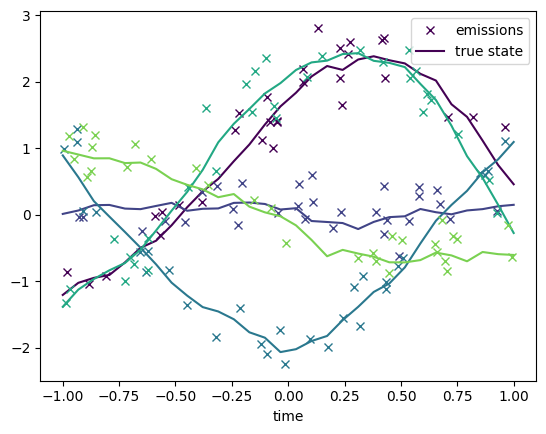

In [6]:
# Plotting some paths and emissions
cmap = matplotlib.colormaps["viridis"]
series_to_plot=min(5, data.shape[0])
for i in range(series_to_plot):
    color = cmap(i/series_to_plot)
    if i == 0:
        emmission_label = "emissions"
        state_label = "true state"
    else:        
        emmission_label = None
        state_label = None

    _=plt.plot(data[i,:,0].T.detach().cpu(), data[i,:,1].T.detach().cpu(), marker="x", linewidth=0, c=color, label=emmission_label)
    _=plt.plot(generator_SDE.ts.detach().cpu(), true_state_series[i,:,0].T.detach().cpu(), marker="", c=color, label=state_label)
    plt.xlabel("time")
    plt.legend()
plt.show()

## Define model setup for training
We define a model of the same class as the generating model:
$$
dz_t = f(z_t, t) dt + g(z_t, t) dW_t = A_\theta z_t d_t + \sigma_\theta \cdot dWt
$$

with emission distribution: $y_t \sim \mathcal N(y_t\vert z_t, \sigma^2_y)$ and initial conditions: $z_0 \sim \mathcal N(\mu_I, \sigma^2_I \cdot I_2)$

For now,  we initialize the parameters $A_\theta$, $\log \sigma_\theta$, $\log \sigma_y$, $\mu_I$ and $\log \sigma_I$ to the true valuse.

In [11]:
# Prior
priormean = torch.zeros(state_dim, device=device)
#prior_log_std = torch.ones(state_dim, device=device) * 0
prior_log_std = true_prior_log_std.clone().detach()
myprior = GaussianPrior(mean=priormean, log_std=prior_log_std, trainable=True, device=device)

# Diffusion term
#log_diff_func = FunctionApproximatorModel(num_features=0, hidden_layers=[], num_outputs=0, nonlin=torch.nn.ReLU(), seed=2, initial_zero=False, device=device)
#mydiffusion = ScalarDiffusion(state_dim, state_dim, log_diff_func, device=device)
mydiffusion = SimpleDiffusion(state_dim, state_dim, log_std=true_diffusion_log_std.clone().detach(), device=device, trainable=True)


# Drift term
mydrift = FunctionApproximatorModel_drift(num_features=state_dim, hidden_layers=[], num_outputs=state_dim, nonlin=torch.nn.ReLU(), seed=2, initial_zero=False, device=device, time_independent=True, bias=False)
#mydrift.hidden_layers[0].weight.data=torch.tensor([[0.0, 2.0], [-2.0, 0.0]])
# Emission
#myemission = GaussianEmission(dim=state_dim, log_std=torch.tensor(.1).log(), trainable=True)
myemission = GaussianEmission(dim=state_dim, log_std=true_emission_log_std.clone().detach(), trainable=True, device=device)


## Building the marginal distribution

In [12]:
condition_mapper = TransformerLatentModel(obs_dim=state_dim, state_dim=state_dim, model_dim=128, time_embed_dim=32, n_heads=4, n_layers=3).to(device)
marginal_func = AffineFlow(state_dim, device=device)
myMarginal = Marginal(marginal_func, mydiffusion, condition_mapper, device=device)


In [13]:

mySDEproblem = SDEproblem(drift=mydrift, 
                          diffusion=mydiffusion, 
                          prior=myprior, 
                          marginal_func=marginal_func, 
                          condition_mapper=condition_mapper, 
                          emission=myemission, 
                          time_dist=time_dist, 
                          t_start=t_start, 
                          t_end=t_end, 
                          device=device)

print(f"Total parameters in mySDEproblem: {sum(p.numel() for p in mySDEproblem.parameters())}")
for k in dict(mySDEproblem.named_parameters()).keys():
    print(k)

print("\n\nGenerating modules parameters")
for net in [generator_drift, generator_diffusion, generator_emission, generator_prior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

print("\n\nSolving modules parameters")
for net in [mydrift, mydiffusion, myemission, myprior]:
    print(f"\n{net._get_name()}:")
    print(dict(net.named_parameters()))

Total parameters in mySDEproblem: 616782
drift.hidden_layers.0.weight
diffusion.log_std
prior.log_std
prior.mean
condition_mapper.encoder.embedding.time_mlp.0.weight
condition_mapper.encoder.embedding.time_mlp.0.bias
condition_mapper.encoder.embedding.time_mlp.2.weight
condition_mapper.encoder.embedding.time_mlp.2.bias
condition_mapper.encoder.embedding.data_proj.weight
condition_mapper.encoder.embedding.data_proj.bias
condition_mapper.encoder.encoder.layers.0.self_attn.in_proj_weight
condition_mapper.encoder.encoder.layers.0.self_attn.in_proj_bias
condition_mapper.encoder.encoder.layers.0.self_attn.out_proj.weight
condition_mapper.encoder.encoder.layers.0.self_attn.out_proj.bias
condition_mapper.encoder.encoder.layers.0.linear1.weight
condition_mapper.encoder.encoder.layers.0.linear1.bias
condition_mapper.encoder.encoder.layers.0.linear2.weight
condition_mapper.encoder.encoder.layers.0.linear2.bias
condition_mapper.encoder.encoder.layers.0.norm1.weight
condition_mapper.encoder.encoder

In [14]:
# Saving true parameters to list, for plotting
def save_models(parameter_dict, models_to_be_saved):
    for model_to_be_saved in models_to_be_saved:
        for parameter_name, parameter_value in model_to_be_saved.named_parameters():
            if parameter_value.data.dim:
                val = parameter_value.data.unsqueeze(0)
            else: val = parameter_value.data
            val = val.ravel().unsqueeze(0)
            fullname = f"{model_to_be_saved._get_name()}.{parameter_name}"
            if fullname in parameter_dict.keys():
                parameter_dict[fullname] = torch.cat([parameter_dict[fullname], val.clone().detach()])
            else: parameter_dict[fullname] = val.clone().detach()

true_parameter_dict ={}
save_models(true_parameter_dict, [generator_drift, generator_diffusion, generator_emission, generator_prior])

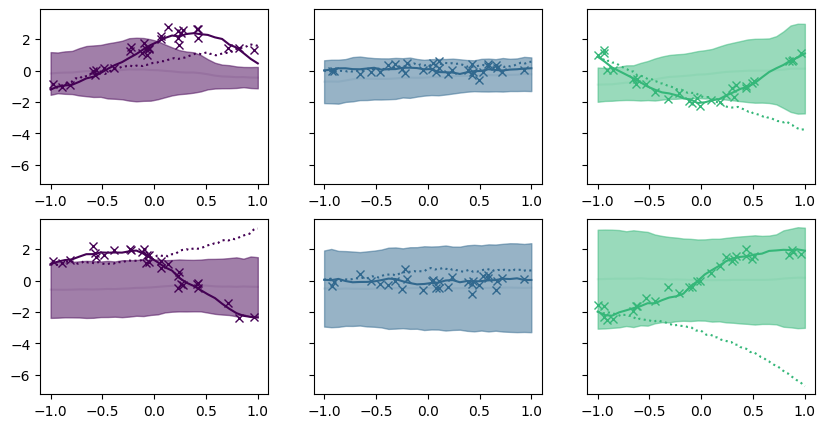

In [15]:
# Plotting the marginal distribution as it looks now
fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, max_num_data=3, device=device)
plt.show()


In [19]:
# train loop
saved_parameter_dict = {}

all_train_losses = []
batch_size = 100
max_step_no = 1000
with torch_seed(0):
    train_loader_ = DataLoader(data, batch_size=batch_size)
epoch_loss = []
epoch_diffusion_loss = []
epoch_prior_loss = []
epoch_reconstruction_loss = []

models_to_be_saved = [mydrift, mydiffusion, myemission, myprior]
saved_models = []

num_batches_train = len(train_loader_)
epoch_steps = []
step_no = 0
#torch.random.manual_seed(0)
epoch = 0
plot_every_epoch = 100
plot_parameters_every_epoch = 100
print_every_epoch = 10

params_for_optim1 = [{"params": m.named_parameters()} for m in models_to_be_saved if len(dict(m.named_parameters()))>0]
params_for_optim2 = mySDEproblem.condition_mapper.named_parameters()
lr1 = torch.tensor(0.05)
lr2 = torch.tensor(0.001)
optimizer1 = torch.optim.Adam(params_for_optim1, lr=lr1)
optimizer2 = torch.optim.Adam(params_for_optim2, lr=lr2)
scheduler=None

epoch=10, 	step=10, 	loss=37.909893, 	diff loss=6.008003, 	prior loss=3.305894, 	rec loss=28.595997,
epoch=20, 	step=20, 	loss=42.539104, 	diff loss=8.164469, 	prior loss=3.020304, 	rec loss=31.354334,
epoch=30, 	step=30, 	loss=33.729622, 	diff loss=10.209518, 	prior loss=3.394797, 	rec loss=20.125305,
epoch=40, 	step=40, 	loss=32.644352, 	diff loss=10.693346, 	prior loss=3.428338, 	rec loss=18.522669,
epoch=50, 	step=50, 	loss=28.421963, 	diff loss=11.716693, 	prior loss=3.336472, 	rec loss=13.368799,
epoch=60, 	step=60, 	loss=38.874809, 	diff loss=11.519780, 	prior loss=3.505431, 	rec loss=23.849598,
epoch=70, 	step=70, 	loss=42.583649, 	diff loss=12.818167, 	prior loss=3.472566, 	rec loss=26.292913,
epoch=80, 	step=80, 	loss=43.059761, 	diff loss=7.526170, 	prior loss=3.027359, 	rec loss=32.506233,
epoch=90, 	step=90, 	loss=53.641907, 	diff loss=7.123698, 	prior loss=3.311278, 	rec loss=43.206928,
epoch=100, 	step=100, 	loss=33.498516, 	diff loss=12.152642, 	prior loss=3.535387, 	re

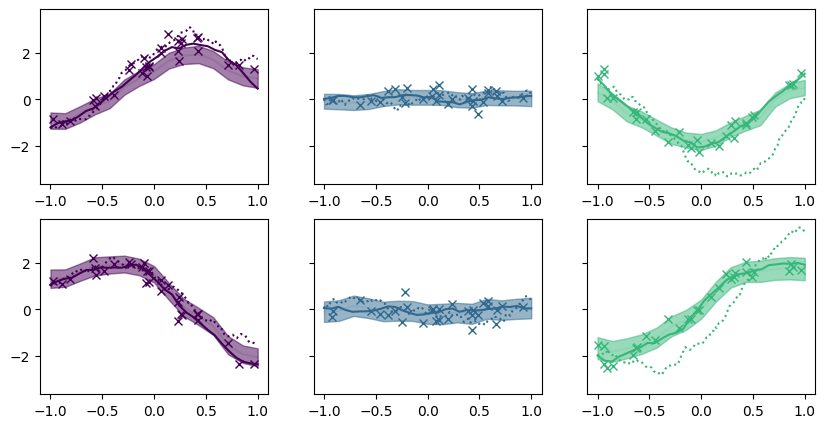

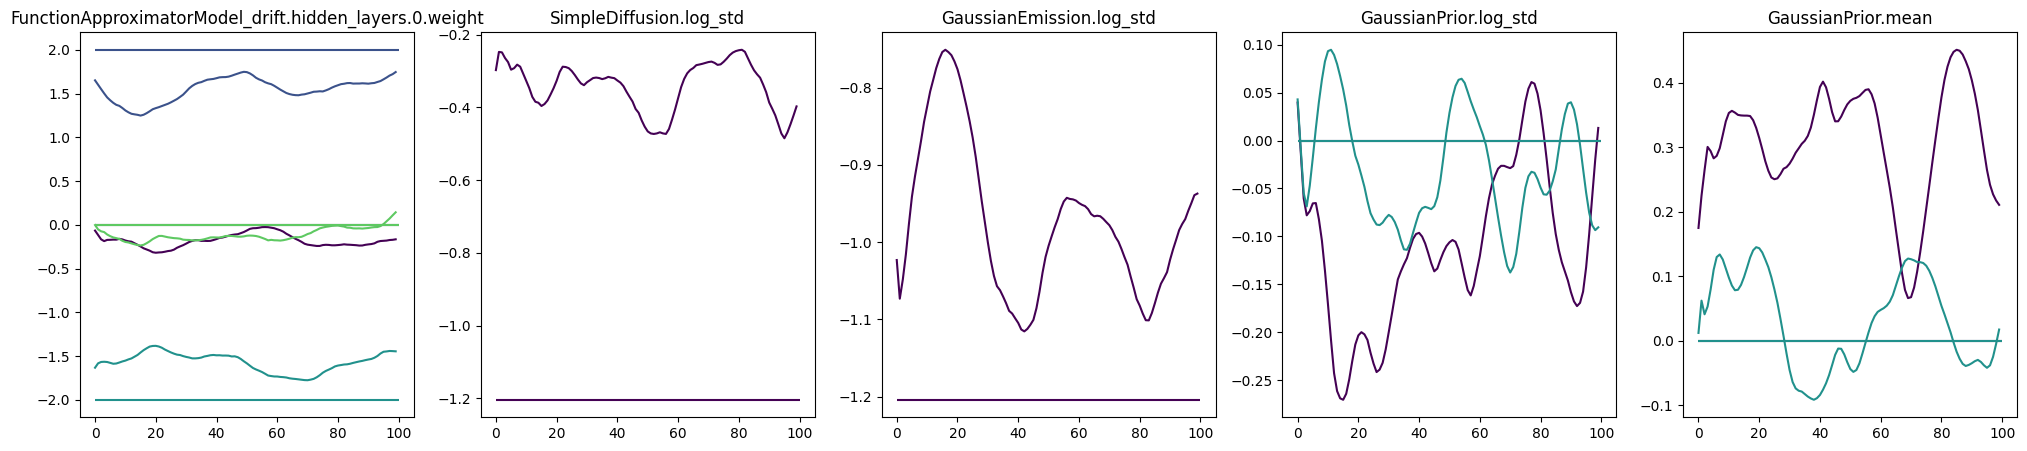

epoch=110, 	step=110, 	loss=51.648712, 	diff loss=12.679011, 	prior loss=3.239518, 	rec loss=35.730186,
epoch=120, 	step=120, 	loss=45.800995, 	diff loss=7.564283, 	prior loss=3.575721, 	rec loss=34.660992,
epoch=130, 	step=130, 	loss=39.362782, 	diff loss=14.187666, 	prior loss=3.721046, 	rec loss=21.454065,
epoch=140, 	step=140, 	loss=36.082878, 	diff loss=10.069008, 	prior loss=3.708565, 	rec loss=22.305304,
epoch=150, 	step=150, 	loss=30.888916, 	diff loss=12.649297, 	prior loss=3.418805, 	rec loss=14.820811,
epoch=160, 	step=160, 	loss=31.777180, 	diff loss=11.601547, 	prior loss=3.441495, 	rec loss=16.734135,
epoch=170, 	step=170, 	loss=30.429205, 	diff loss=7.396498, 	prior loss=3.457645, 	rec loss=19.575062,
epoch=180, 	step=180, 	loss=22.853439, 	diff loss=10.862464, 	prior loss=4.050701, 	rec loss=7.940275,
epoch=190, 	step=190, 	loss=32.739265, 	diff loss=7.674189, 	prior loss=3.663676, 	rec loss=21.401400,
epoch=200, 	step=200, 	loss=31.825451, 	diff loss=12.359530, 	prior 

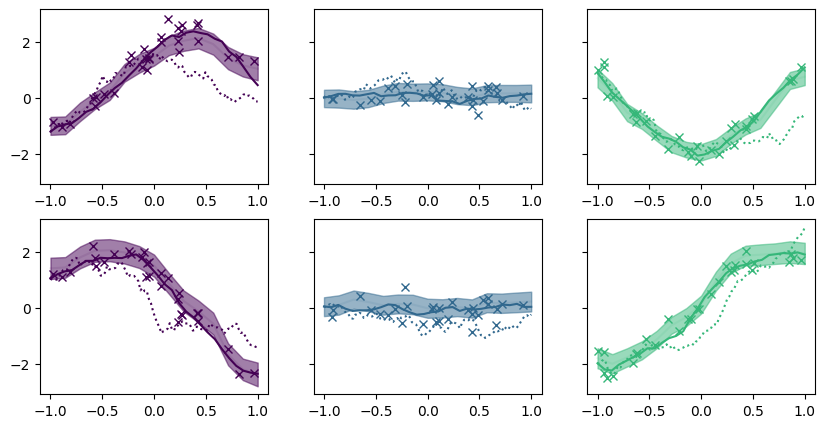

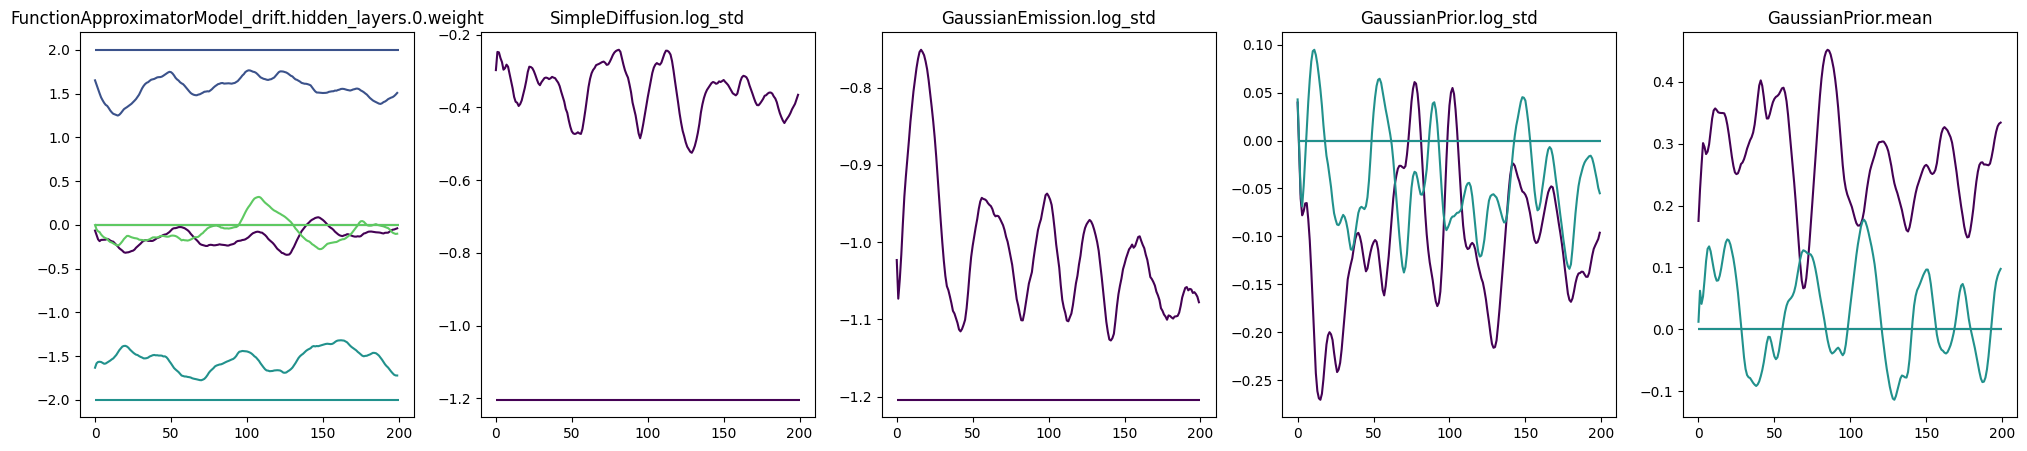

epoch=210, 	step=210, 	loss=37.080311, 	diff loss=10.589319, 	prior loss=3.369457, 	rec loss=23.121531,
epoch=220, 	step=220, 	loss=32.788437, 	diff loss=9.336250, 	prior loss=3.818064, 	rec loss=19.634123,
epoch=230, 	step=230, 	loss=35.683197, 	diff loss=10.548317, 	prior loss=3.226681, 	rec loss=21.908197,
epoch=240, 	step=240, 	loss=27.524740, 	diff loss=15.741287, 	prior loss=3.229726, 	rec loss=8.553728,
epoch=250, 	step=250, 	loss=44.546539, 	diff loss=17.134312, 	prior loss=3.861661, 	rec loss=23.550564,
epoch=260, 	step=260, 	loss=27.074163, 	diff loss=8.955436, 	prior loss=3.040568, 	rec loss=15.078158,
epoch=270, 	step=270, 	loss=34.501331, 	diff loss=14.229614, 	prior loss=3.470286, 	rec loss=16.801430,
epoch=280, 	step=280, 	loss=36.807991, 	diff loss=14.528981, 	prior loss=3.139117, 	rec loss=19.139894,
epoch=290, 	step=290, 	loss=25.142105, 	diff loss=10.168035, 	prior loss=3.634106, 	rec loss=11.339964,
epoch=300, 	step=300, 	loss=37.647663, 	diff loss=8.731363, 	prior 

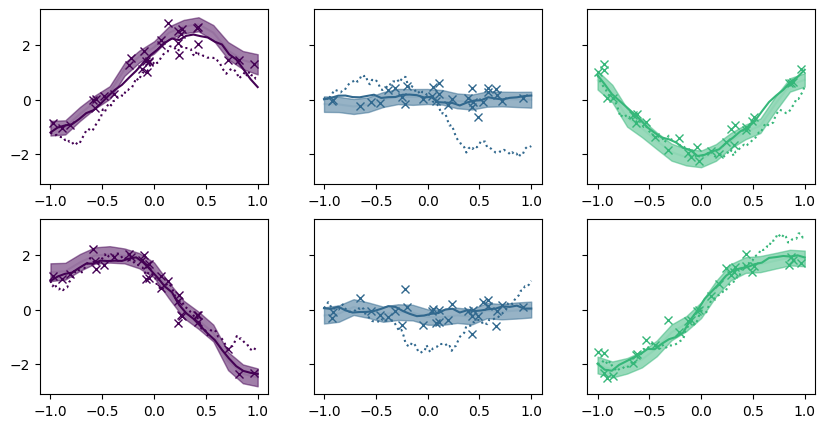

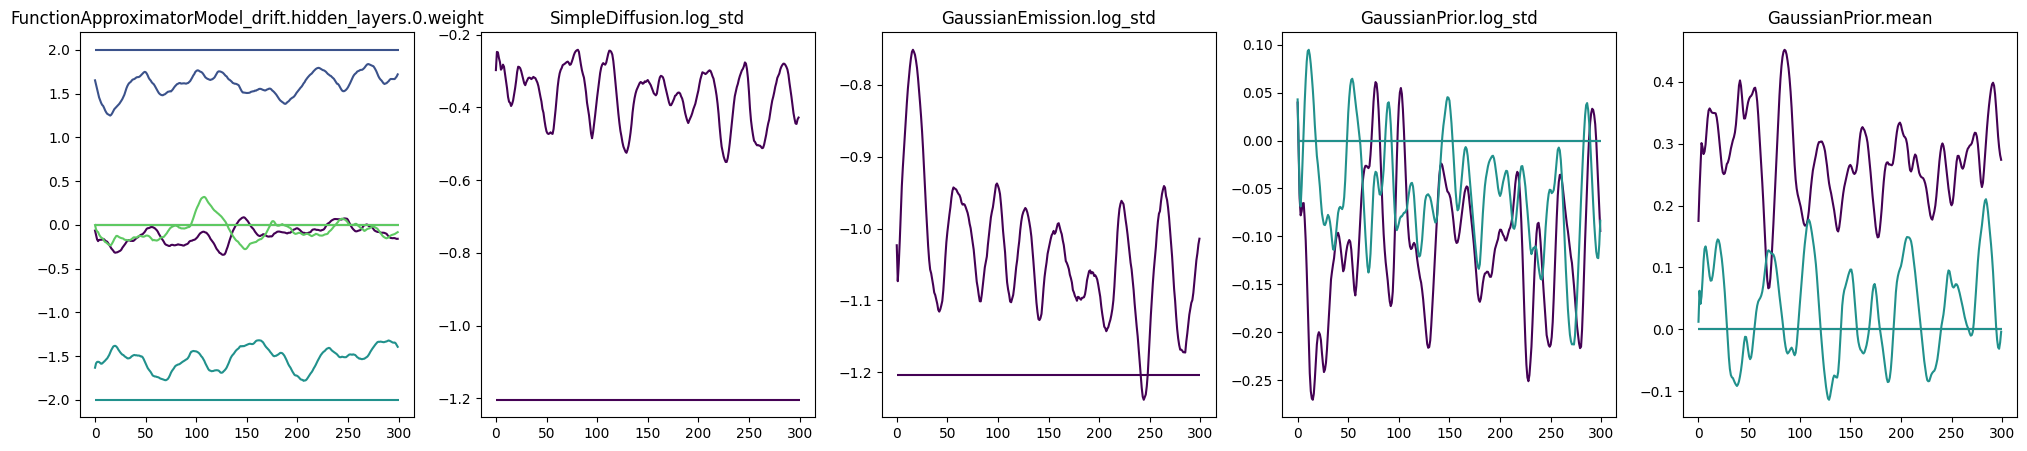

epoch=310, 	step=310, 	loss=32.810051, 	diff loss=5.508165, 	prior loss=3.129201, 	rec loss=24.172686,
epoch=320, 	step=320, 	loss=28.399677, 	diff loss=9.921225, 	prior loss=3.631833, 	rec loss=14.846621,
epoch=330, 	step=330, 	loss=35.234219, 	diff loss=14.065699, 	prior loss=3.760505, 	rec loss=17.408016,
epoch=340, 	step=340, 	loss=30.561665, 	diff loss=13.238722, 	prior loss=3.770329, 	rec loss=13.552615,
epoch=350, 	step=350, 	loss=36.159069, 	diff loss=7.632185, 	prior loss=3.135127, 	rec loss=25.391758,
epoch=360, 	step=360, 	loss=32.953785, 	diff loss=8.894855, 	prior loss=3.933059, 	rec loss=20.125872,
epoch=370, 	step=370, 	loss=35.262348, 	diff loss=9.714624, 	prior loss=3.775035, 	rec loss=21.772686,
epoch=380, 	step=380, 	loss=31.019318, 	diff loss=7.904653, 	prior loss=3.587140, 	rec loss=19.527523,
epoch=390, 	step=390, 	loss=34.512676, 	diff loss=9.196825, 	prior loss=3.749438, 	rec loss=21.566416,
epoch=400, 	step=400, 	loss=35.680122, 	diff loss=13.514178, 	prior los

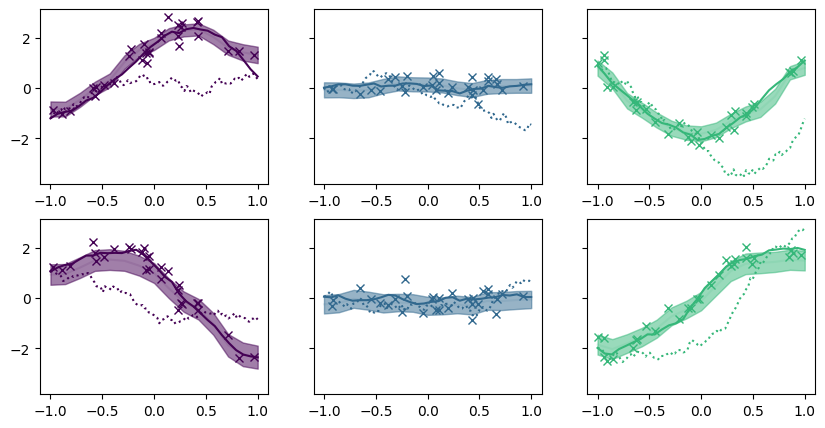

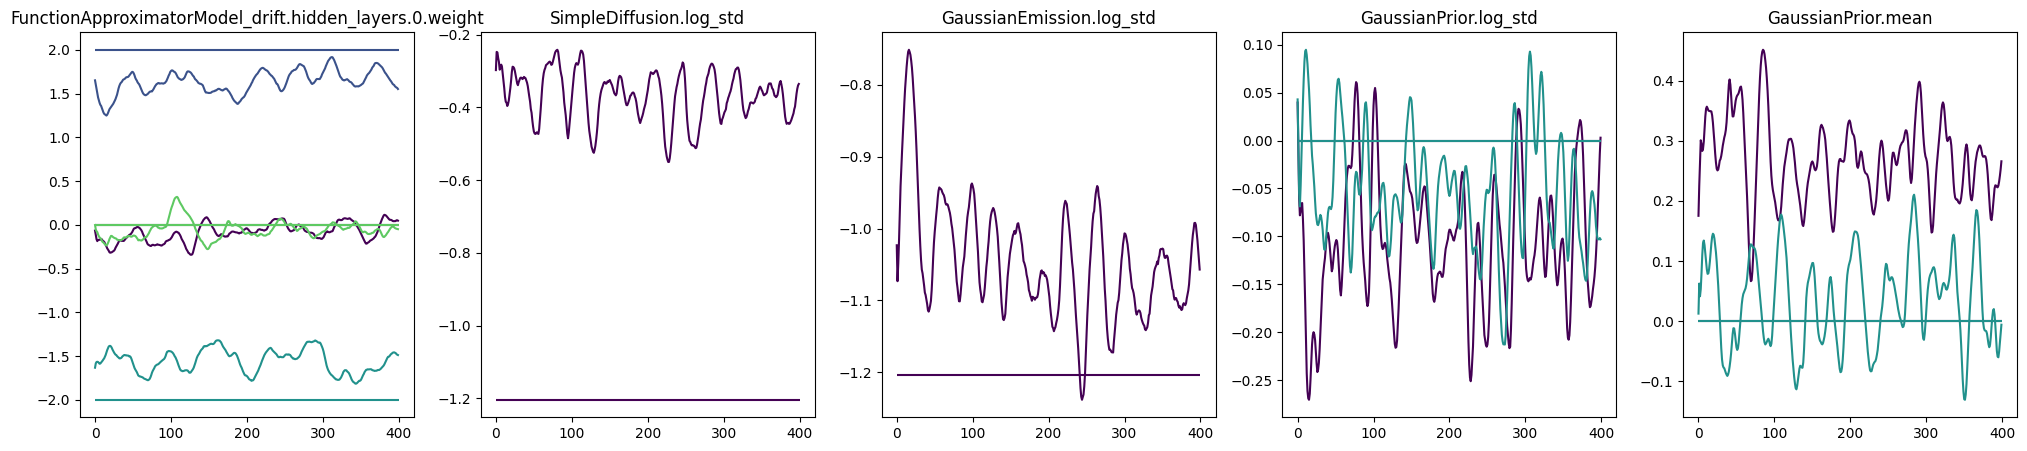

epoch=410, 	step=410, 	loss=58.973949, 	diff loss=14.438463, 	prior loss=3.203421, 	rec loss=41.332066,
epoch=420, 	step=420, 	loss=40.251457, 	diff loss=9.738367, 	prior loss=3.865261, 	rec loss=26.647827,
epoch=430, 	step=430, 	loss=52.407593, 	diff loss=11.670597, 	prior loss=3.689495, 	rec loss=37.047501,
epoch=440, 	step=440, 	loss=40.261242, 	diff loss=5.710561, 	prior loss=3.001821, 	rec loss=31.548859,
epoch=450, 	step=450, 	loss=27.552917, 	diff loss=6.787006, 	prior loss=3.436166, 	rec loss=17.329744,
epoch=460, 	step=460, 	loss=39.163128, 	diff loss=10.619902, 	prior loss=2.967993, 	rec loss=25.575233,
epoch=470, 	step=470, 	loss=29.792599, 	diff loss=10.113744, 	prior loss=3.538860, 	rec loss=16.139996,
epoch=480, 	step=480, 	loss=28.688684, 	diff loss=10.259976, 	prior loss=3.796429, 	rec loss=14.632280,
epoch=490, 	step=490, 	loss=35.159000, 	diff loss=11.070163, 	prior loss=3.230408, 	rec loss=20.858427,
epoch=500, 	step=500, 	loss=41.206989, 	diff loss=8.993509, 	prior 

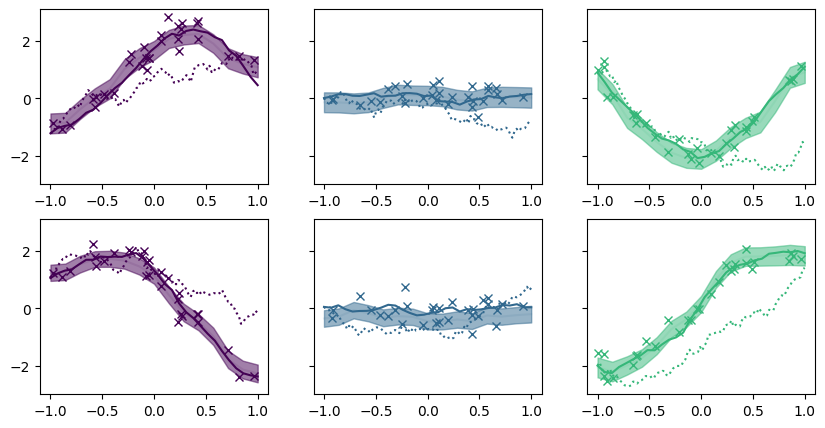

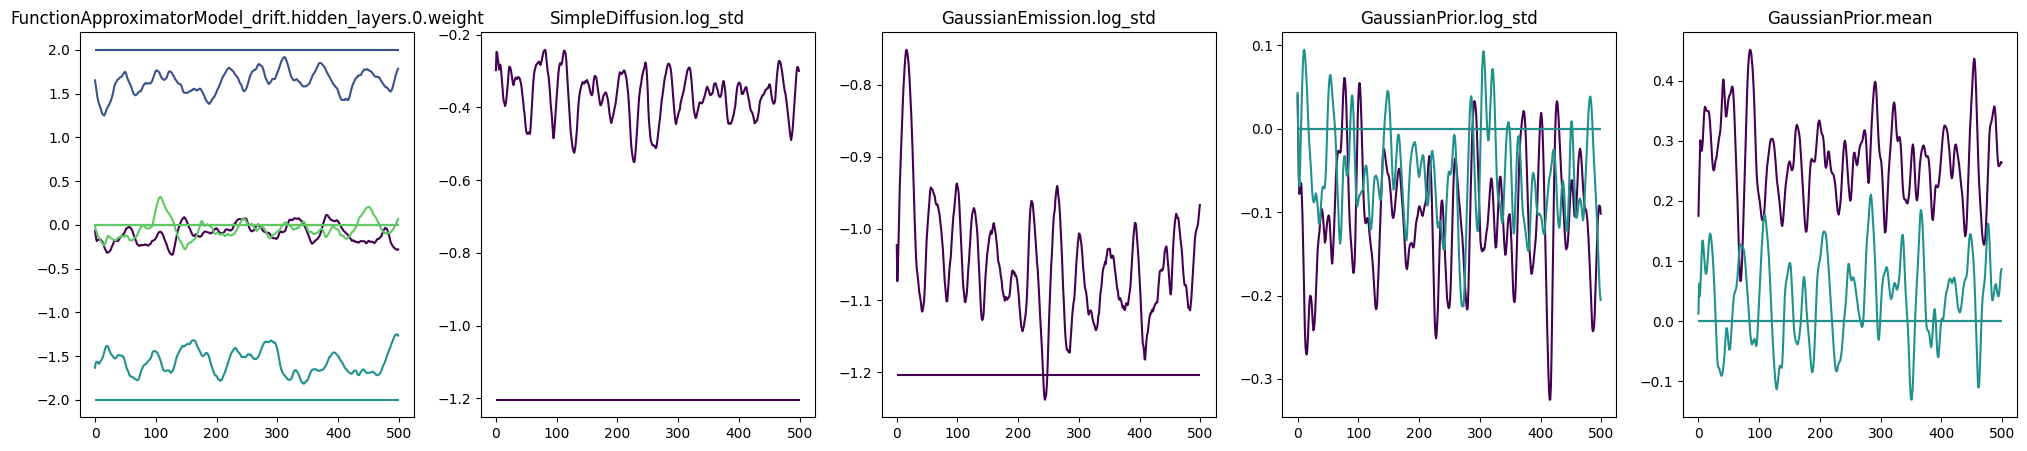

epoch=510, 	step=510, 	loss=40.020130, 	diff loss=8.963846, 	prior loss=3.206836, 	rec loss=27.849451,
epoch=520, 	step=520, 	loss=30.762615, 	diff loss=10.538786, 	prior loss=3.441303, 	rec loss=16.782526,
epoch=530, 	step=530, 	loss=36.304756, 	diff loss=16.575619, 	prior loss=3.151653, 	rec loss=16.577480,
epoch=540, 	step=540, 	loss=31.392221, 	diff loss=12.164781, 	prior loss=3.084884, 	rec loss=16.142557,
epoch=550, 	step=550, 	loss=30.318243, 	diff loss=12.284090, 	prior loss=3.281896, 	rec loss=14.752254,
epoch=560, 	step=560, 	loss=35.891563, 	diff loss=12.936295, 	prior loss=3.187636, 	rec loss=19.767633,
epoch=570, 	step=570, 	loss=37.760975, 	diff loss=8.701296, 	prior loss=3.856286, 	rec loss=25.203390,
epoch=580, 	step=580, 	loss=24.830736, 	diff loss=12.638566, 	prior loss=3.101727, 	rec loss=9.090444,
epoch=590, 	step=590, 	loss=24.750301, 	diff loss=11.256546, 	prior loss=3.676192, 	rec loss=9.817566,
epoch=600, 	step=600, 	loss=48.717052, 	diff loss=11.378392, 	prior 

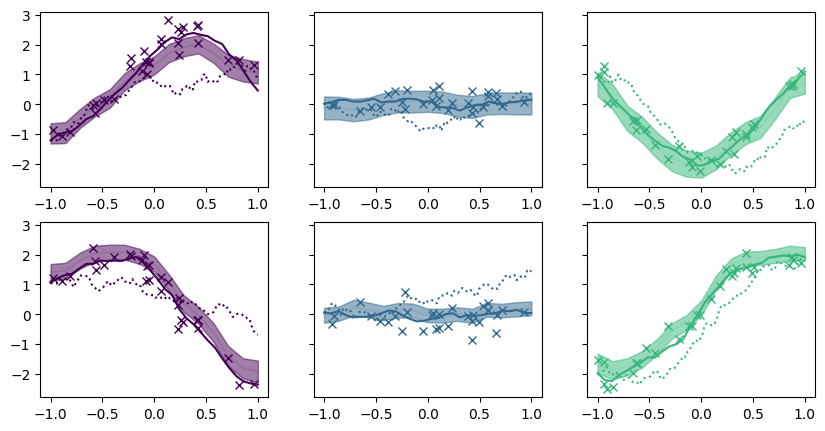

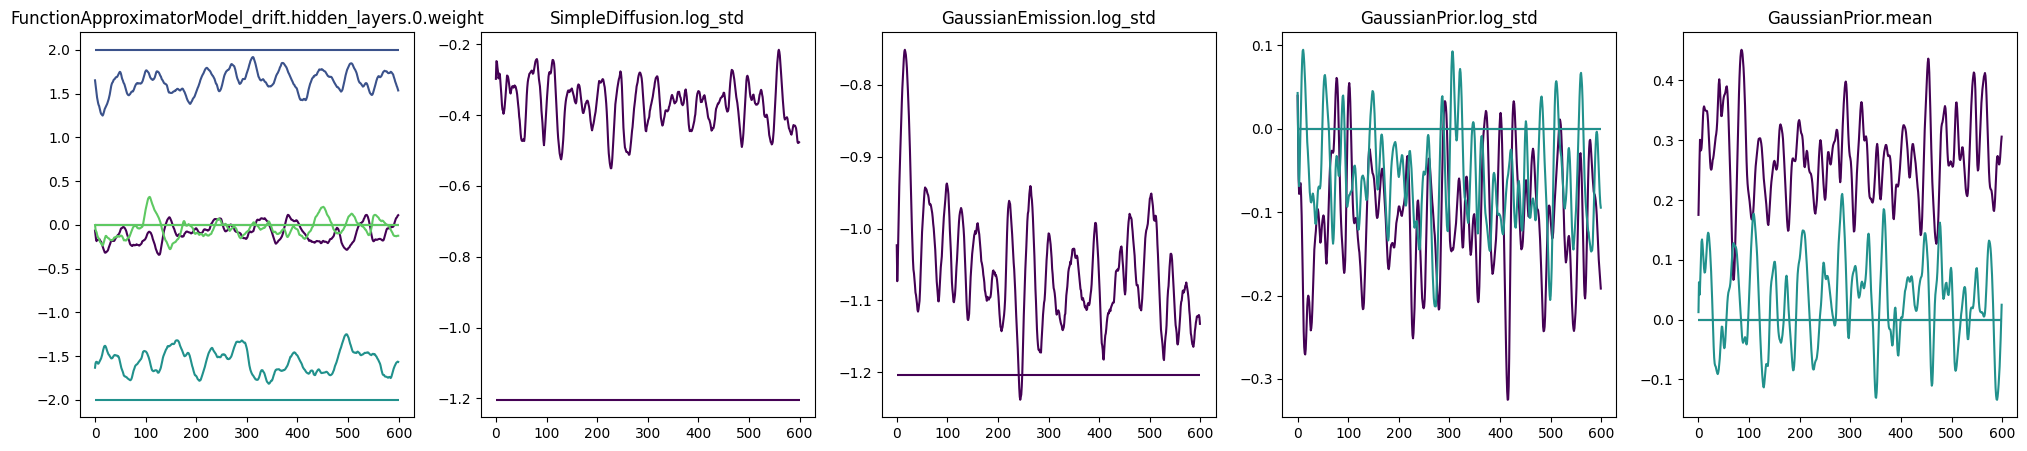

epoch=610, 	step=610, 	loss=36.650375, 	diff loss=11.999327, 	prior loss=3.416900, 	rec loss=21.234150,
epoch=620, 	step=620, 	loss=42.289154, 	diff loss=9.460551, 	prior loss=3.446809, 	rec loss=29.381794,
epoch=630, 	step=630, 	loss=41.261158, 	diff loss=9.477916, 	prior loss=3.832497, 	rec loss=27.950745,
epoch=640, 	step=640, 	loss=35.370373, 	diff loss=6.620842, 	prior loss=3.530739, 	rec loss=25.218792,
epoch=650, 	step=650, 	loss=27.019434, 	diff loss=8.022527, 	prior loss=3.277565, 	rec loss=15.719343,
epoch=660, 	step=660, 	loss=26.523962, 	diff loss=10.956621, 	prior loss=3.614996, 	rec loss=11.952347,
epoch=670, 	step=670, 	loss=41.009514, 	diff loss=10.031916, 	prior loss=3.574515, 	rec loss=27.403088,
epoch=680, 	step=680, 	loss=29.468725, 	diff loss=9.549647, 	prior loss=3.666411, 	rec loss=16.252670,
epoch=690, 	step=690, 	loss=26.141876, 	diff loss=10.226434, 	prior loss=3.793939, 	rec loss=12.121504,
epoch=700, 	step=700, 	loss=42.339542, 	diff loss=11.432710, 	prior l

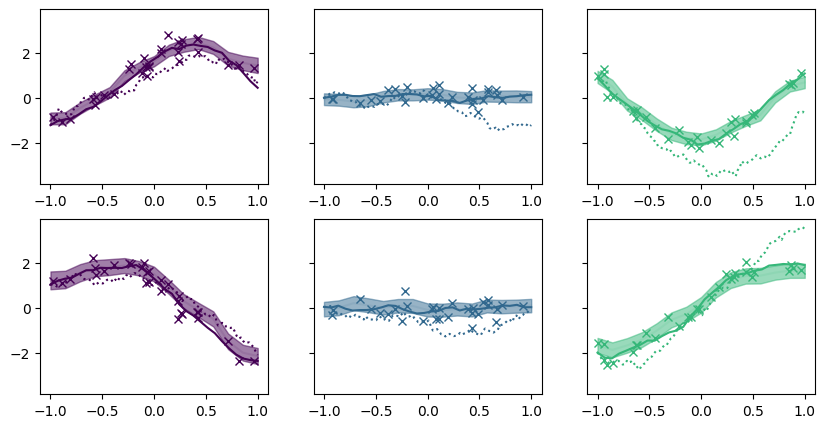

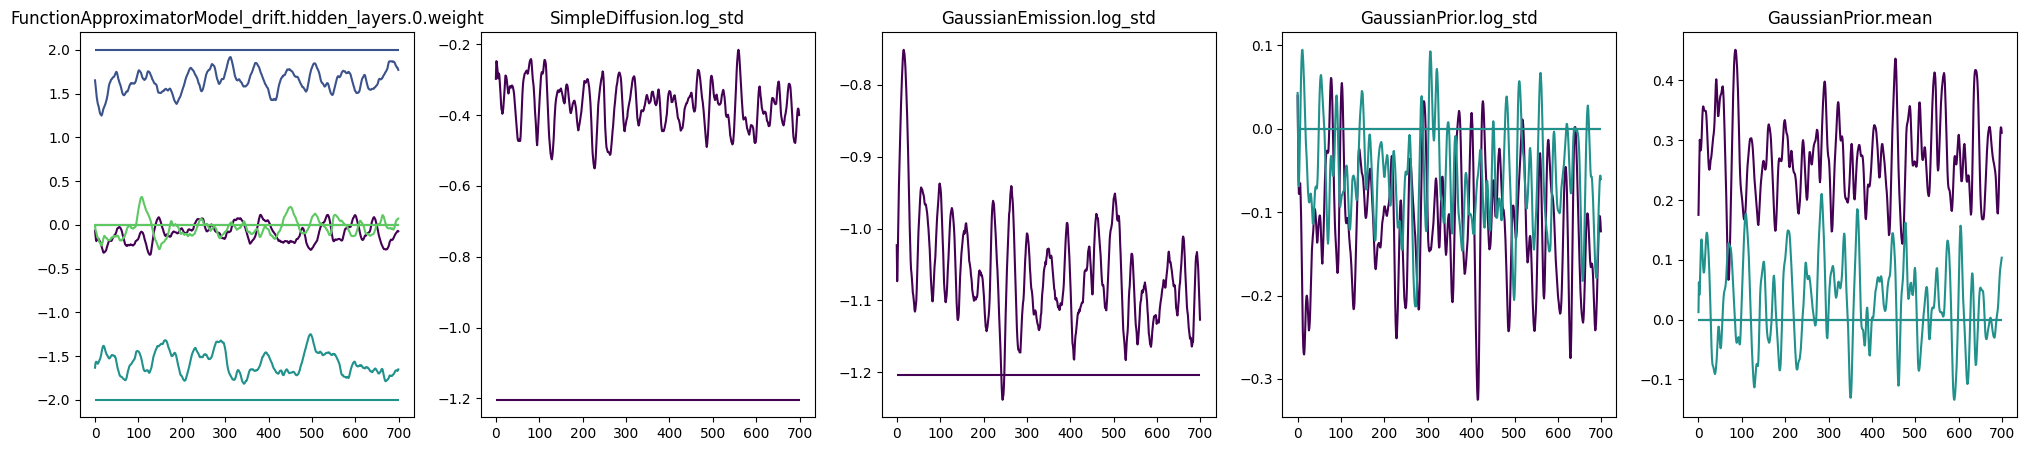

epoch=710, 	step=710, 	loss=50.922829, 	diff loss=7.630128, 	prior loss=3.569492, 	rec loss=39.723206,
epoch=720, 	step=720, 	loss=37.685875, 	diff loss=13.423327, 	prior loss=3.785209, 	rec loss=20.477339,
epoch=730, 	step=730, 	loss=27.740253, 	diff loss=9.674454, 	prior loss=3.112550, 	rec loss=14.953247,
epoch=740, 	step=740, 	loss=15.249048, 	diff loss=8.398119, 	prior loss=3.238818, 	rec loss=3.612112,
epoch=750, 	step=750, 	loss=39.413002, 	diff loss=7.046700, 	prior loss=3.712576, 	rec loss=28.653727,
epoch=760, 	step=760, 	loss=36.411823, 	diff loss=8.692758, 	prior loss=3.531352, 	rec loss=24.187712,
epoch=770, 	step=770, 	loss=34.508148, 	diff loss=6.372478, 	prior loss=3.599833, 	rec loss=24.535839,
epoch=780, 	step=780, 	loss=27.565083, 	diff loss=6.881980, 	prior loss=3.264755, 	rec loss=17.418350,
epoch=790, 	step=790, 	loss=31.367315, 	diff loss=9.434474, 	prior loss=3.408028, 	rec loss=18.524815,
epoch=800, 	step=800, 	loss=39.977318, 	diff loss=10.046045, 	prior loss=

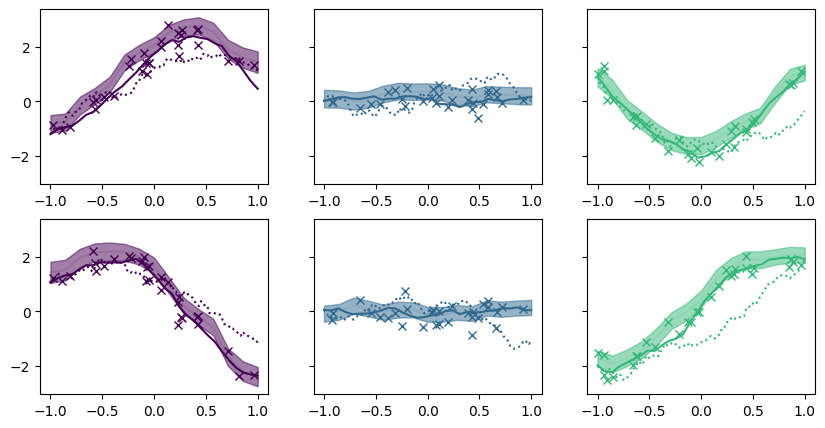

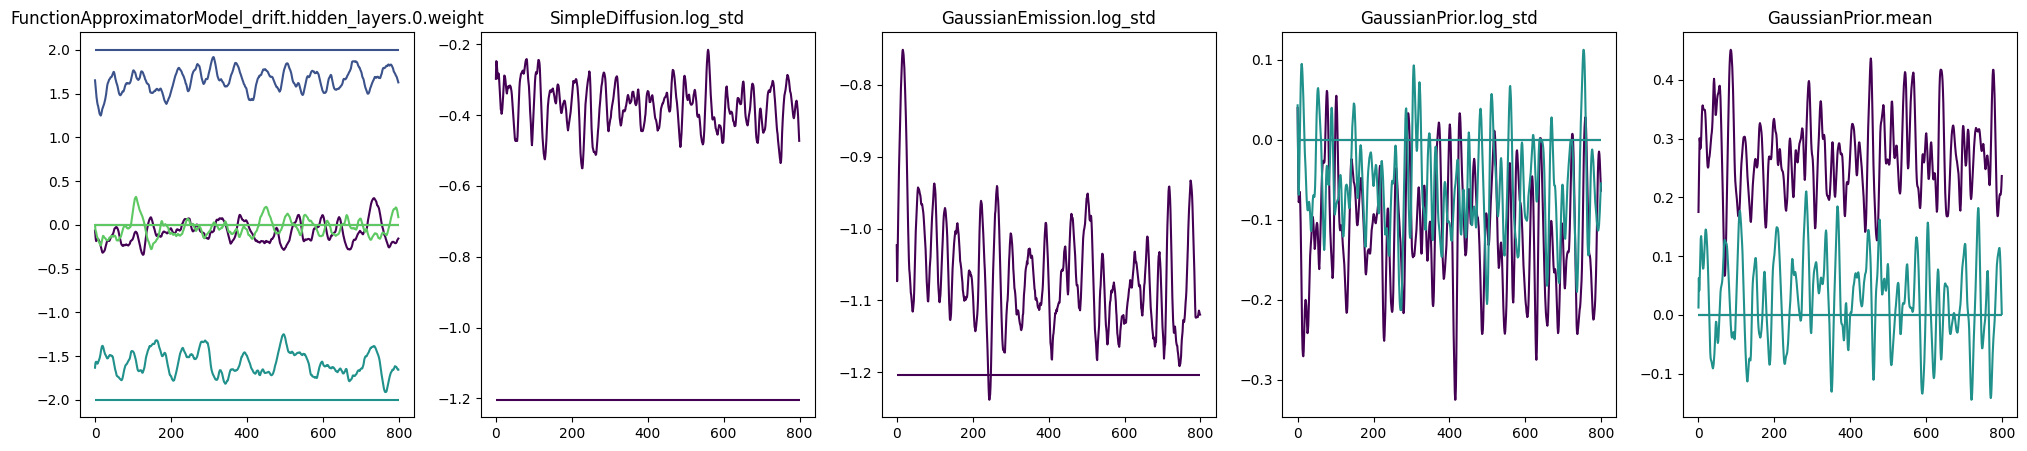

epoch=810, 	step=810, 	loss=32.818481, 	diff loss=13.114792, 	prior loss=3.510005, 	rec loss=16.193684,
epoch=820, 	step=820, 	loss=35.483887, 	diff loss=12.154360, 	prior loss=3.372006, 	rec loss=19.957523,
epoch=830, 	step=830, 	loss=37.377087, 	diff loss=11.143611, 	prior loss=3.693694, 	rec loss=22.539783,
epoch=840, 	step=840, 	loss=18.443125, 	diff loss=8.411177, 	prior loss=3.321378, 	rec loss=6.710570,
epoch=850, 	step=850, 	loss=76.988770, 	diff loss=12.773194, 	prior loss=3.329934, 	rec loss=60.885639,
epoch=860, 	step=860, 	loss=27.179754, 	diff loss=8.455625, 	prior loss=3.534818, 	rec loss=15.189314,
epoch=870, 	step=870, 	loss=25.811131, 	diff loss=11.394060, 	prior loss=3.557160, 	rec loss=10.859909,
epoch=880, 	step=880, 	loss=26.802149, 	diff loss=13.686358, 	prior loss=3.658726, 	rec loss=9.457065,
epoch=890, 	step=890, 	loss=17.828785, 	diff loss=8.671333, 	prior loss=3.204840, 	rec loss=5.952609,
epoch=900, 	step=900, 	loss=44.535439, 	diff loss=13.477923, 	prior lo

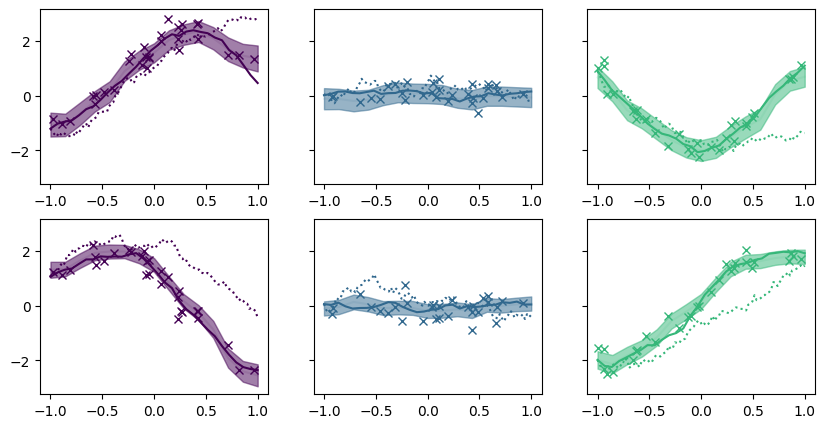

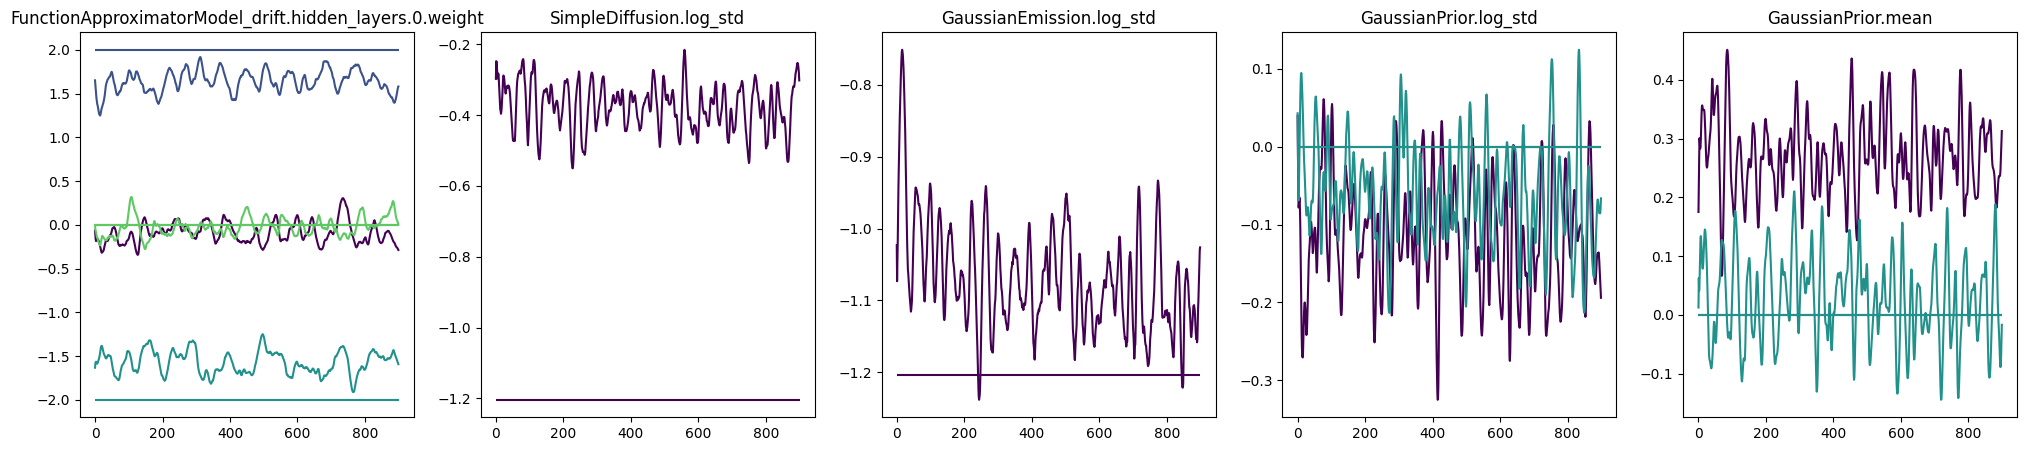

epoch=910, 	step=910, 	loss=32.992096, 	diff loss=10.130661, 	prior loss=3.630671, 	rec loss=19.230764,
epoch=920, 	step=920, 	loss=29.945744, 	diff loss=11.430840, 	prior loss=3.931018, 	rec loss=14.583883,
epoch=930, 	step=930, 	loss=27.701092, 	diff loss=8.581964, 	prior loss=3.465369, 	rec loss=15.653758,
epoch=940, 	step=940, 	loss=25.257940, 	diff loss=9.508496, 	prior loss=3.460597, 	rec loss=12.288847,
epoch=950, 	step=950, 	loss=46.809059, 	diff loss=10.201096, 	prior loss=3.626621, 	rec loss=32.981335,
epoch=960, 	step=960, 	loss=52.141335, 	diff loss=11.095815, 	prior loss=3.165858, 	rec loss=37.879662,
epoch=970, 	step=970, 	loss=47.234940, 	diff loss=13.548883, 	prior loss=3.196744, 	rec loss=30.489313,
epoch=980, 	step=980, 	loss=24.955250, 	diff loss=8.763768, 	prior loss=4.019175, 	rec loss=12.172307,
epoch=990, 	step=990, 	loss=19.081528, 	diff loss=7.510293, 	prior loss=3.838174, 	rec loss=7.733061,
epoch=1000, 	step=1000, 	loss=35.151985, 	diff loss=11.642462, 	prior

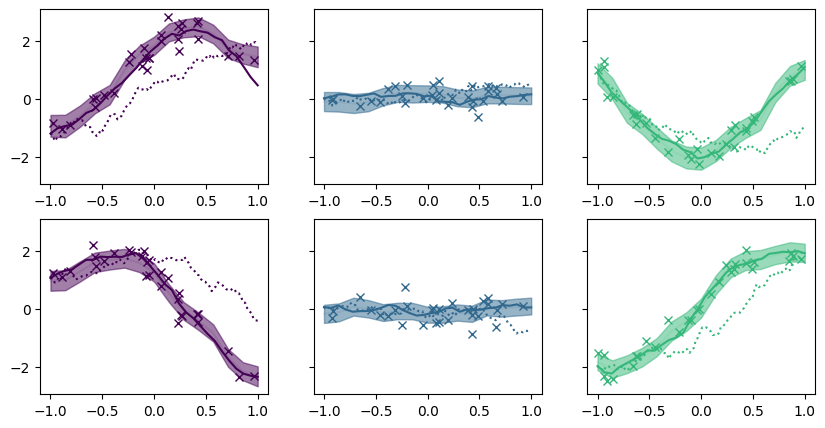

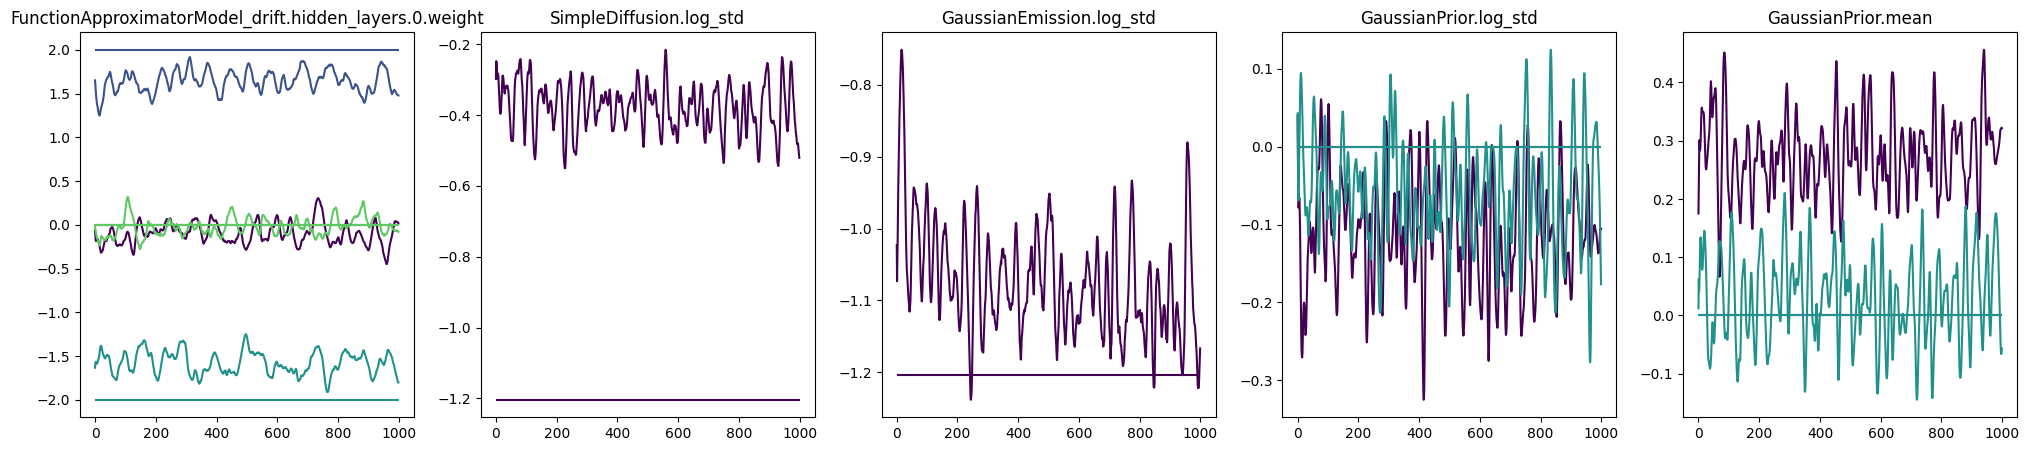

In [20]:
while True:
    epoch_loss.append(0) 
    epoch_diffusion_loss.append(0) 
    epoch_prior_loss.append(0) 
    epoch_reconstruction_loss.append(0) 

    epoch += 1
    save_models(saved_parameter_dict, models_to_be_saved)

    for data_batch in train_loader_:
    #_, data_batch =next(enumerate(train_loader_))
        this_batch_size = len(data_batch)
        if step_no%100 == 0:
            print(f"epoch {epoch}, step_no {step_no}, batch size {this_batch_size}", end="\r")

        #print(f"step_no {step_no}, batch size {this_batch_size}")
        mySDEproblem.train()
        optimizer1.zero_grad()
        optimizer2.zero_grad()
        diffusion_loss, prior_loss, reconstruction_loss = mySDEproblem.ELBO(data_batch)
        sum_loss = (diffusion_loss + prior_loss*1 + reconstruction_loss).mean(dim=0)
        sum_loss.backward()
        all_train_losses.append(sum_loss.item())
        epoch_loss[-1] += sum_loss.item() / num_batches_train
        epoch_diffusion_loss[-1] += diffusion_loss.mean(dim=0).item() / num_batches_train
        epoch_prior_loss[-1] += prior_loss.mean(dim=0).item() / num_batches_train
        epoch_reconstruction_loss[-1] += reconstruction_loss.mean(dim=0).item() / num_batches_train
        step_no += 1

        optimizer1.step()
        optimizer2.step()

    if (epoch % print_every_epoch) ==0:
        string1 = f"epoch={len(epoch_loss)}, \tstep={step_no}, "
        string2 = f"\tloss={epoch_loss[-1] :2.6f}, \tdiff loss={epoch_diffusion_loss[-1] :2.6f}, "
        string3 = f"\tprior loss={epoch_prior_loss[-1] :2.6f}, \trec loss={epoch_reconstruction_loss[-1] :2.6f},"
        #string4 = f"\tlr={optimizer.param_groups[0]['lr'].item():2.7f}"
        print(string1 + string2 + string3)

    if (epoch % plot_every_epoch)==0:
        fig, axes = plot_marginal(mySDEproblem, data, state_dim, axes=None, true_states=true_state_series, 
                          true_states_ts=generator_SDE.ts, num_samples=100, num_timesteps = 15, max_num_data=3)
        plt.show()

    if (epoch % plot_parameters_every_epoch)==0:
        fig, axes = plot_parameter_history(true_parameter_dict, saved_parameter_dict, step_no)
        plt.show()
        #pass

    if scheduler:
        scheduler.step()
    if step_no >= max_step_no: break


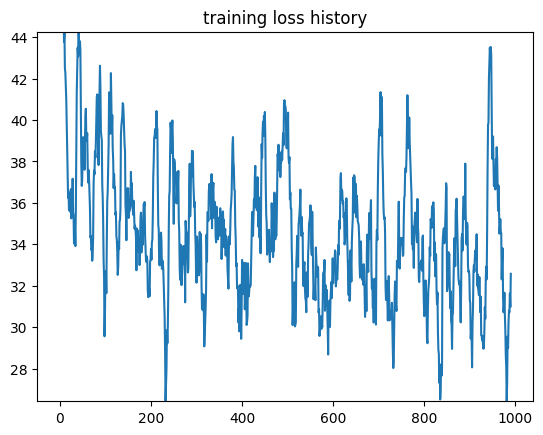

In [24]:

all_train_losses_t = torch.tensor(all_train_losses)

def moving_average(a, n=3):
    ret = a.cumsum(dim=0)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

train_loss_ma = moving_average(all_train_losses_t, 10)
plt.plot(train_loss_ma)
plt.ylim(train_loss_ma.min(), torch.quantile(train_loss_ma, .99))
plt.title("training loss history")
plt.show()
